# Visualizations — TDTU QA System

Tất cả chart cho report. Chạy sau khi NB05 hoàn tất.

**Output:** `visualize/*.png` (6 figures)

In [4]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

if os.path.exists('/content/'):
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/NLP_Final/Source'
else:
    BASE = '..'

RESULTS  = f'{BASE}/results'
SAVE_DIR = f'{BASE}/visualize'
os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':      11,
    'axes.titlesize': 13,
    'figure.dpi':     150,
    'savefig.dpi':    300,
    'savefig.bbox':   'tight',
})

COLORS = {'A': '#6c8ebf', 'B': '#82b366', 'C': '#d6a520', 'D': '#ae4132'}
CFG_LABELS = {
    'A': 'Base, no RAG',
    'B': 'Base + RAG',
    'C': 'Fine-tuned, no RAG',
    'D': 'Fine-tuned + RAG',
}
print('Setup done. BASE =', BASE)

Setup done. BASE = ..


## 1. Training Loss Curve

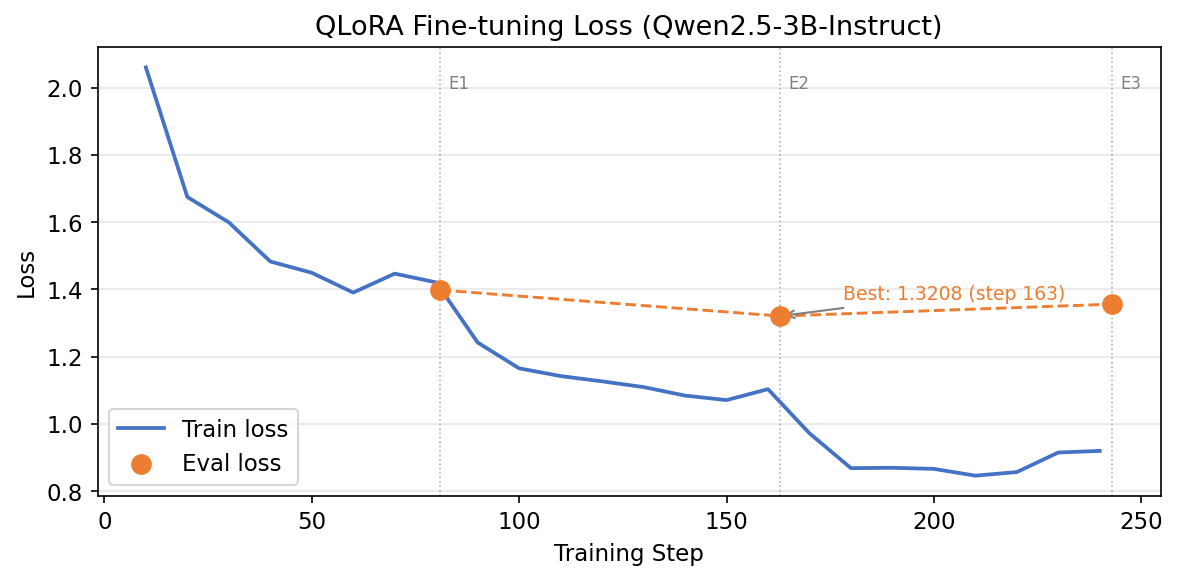

Saved → 01_training_loss.png


In [2]:
with open(f'{BASE}/models/sft_checkpoint/checkpoint-243/trainer_state.json') as f:
    state = json.load(f)

train_steps, train_loss = [], []
eval_steps,  eval_loss  = [], []
for entry in state['log_history']:
    if 'loss' in entry:
        train_steps.append(entry['step'])
        train_loss.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_steps.append(entry['step'])
        eval_loss.append(entry['eval_loss'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_steps, train_loss, color='#4472c4', linewidth=1.8, label='Train loss')
ax.scatter(eval_steps, eval_loss, color='#ed7d31', s=80, zorder=5, label='Eval loss')
ax.plot(eval_steps, eval_loss, color='#ed7d31', linewidth=1.4, linestyle='--')

best_idx = int(np.argmin(eval_loss))
ax.annotate(
    f'Best: {eval_loss[best_idx]:.4f} (step {eval_steps[best_idx]})',
    xy=(eval_steps[best_idx], eval_loss[best_idx]),
    xytext=(eval_steps[best_idx] + 15, eval_loss[best_idx] + 0.05),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='#ed7d31',
)
for epoch, step in [(1, 81), (2, 163), (3, 243)]:
    ax.axvline(step, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.text(step + 2, max(train_loss) * 0.99, f'E{epoch}', fontsize=8, color='gray', va='top')

ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('QLoRA Fine-tuning Loss (Qwen2.5-3B-Instruct)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_training_loss.png')
plt.show()
print('Saved → 01_training_loss.png')

## 2. Automated Metrics Bar Chart (A/B/C/D)

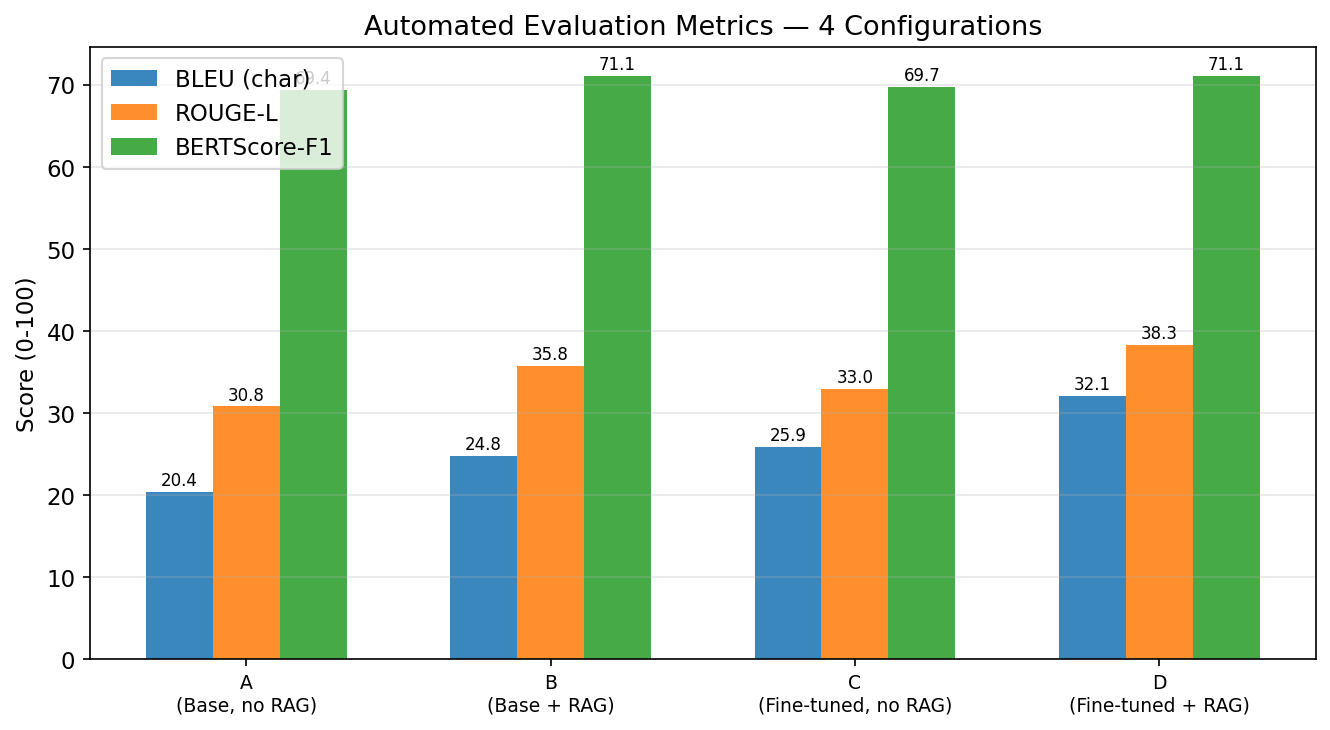

Saved → 02_auto_metrics.png


In [3]:
with open(f'{RESULTS}/eval_summary.json') as f:
    auto = json.load(f)

cfgs    = ['A', 'B', 'C', 'D']
metrics = ['bleu', 'rougeL', 'bertscore_F1']
mlabels = ['BLEU (char)', 'ROUGE-L', 'BERTScore-F1']
x = np.arange(len(cfgs))

fig, ax = plt.subplots(figsize=(9, 5))
for i, (m, ml) in enumerate(zip(metrics, mlabels)):
    vals = [auto[c][m] for c in cfgs]
    bars = ax.bar(x + (i - 1) * 0.22, vals, 0.22, label=ml, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n({CFG_LABELS[c]})' for c in cfgs], fontsize=9)
ax.set_ylabel('Score (0-100)')
ax.set_title('Automated Evaluation Metrics — 4 Configurations')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_auto_metrics.png')
plt.show()
print('Saved → 02_auto_metrics.png')

## 3. Human Evaluation Bar Chart

In [ ]:
with open(f'{RESULTS}/human_eval_summary.json') as f:
    human = json.load(f)

dims    = ['accuracy_1_5', 'completeness_1_5', 'fluency_1_5',
           'conciseness_1_5', 'no_hallucination_1_5', 'composite']
dlabels = ['Accuracy', 'Completeness', 'Fluency',
           'Conciseness', 'No-Hallucination', 'Composite']
x = np.arange(len(dims))

fig, ax = plt.subplots(figsize=(12, 5))
for i, cfg in enumerate(['A', 'B', 'C', 'D']):
    means = [human[cfg][d]['mean'] for d in dims]
    stds  = [human[cfg][d]['std']  for d in dims]
    ax.bar(x + (i - 1.5) * 0.18, means, 0.18,
           yerr=stds, capsize=3,
           color=COLORS[cfg], alpha=0.85,
           label=f'{cfg}: {CFG_LABELS[cfg]}')

ax.set_xticks(x)
ax.set_xticklabels(dlabels, fontsize=10)
ax.set_ylabel('Mean Score (1-5)')
ax.set_ylim(0, 5.8)
ax.set_title('Human Evaluation — Mean ± Std per Dimension')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.4)
ax.axvspan(len(dims) - 1 - 0.4, len(dims) - 1 + 0.4, color='gold', alpha=0.12, zorder=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_human_eval.png')
plt.show()
print('Saved → 03_human_eval.png')

## 4. Radar Chart — Human Evaluation

In [ ]:
dims5    = ['accuracy_1_5', 'completeness_1_5', 'fluency_1_5',
            'conciseness_1_5', 'no_hallucination_1_5']
dlabels5 = ['Accuracy', 'Completeness', 'Fluency', 'Conciseness', 'No-Hallucination']
N        = len(dims5)
angles   = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for cfg in ['A', 'B', 'C', 'D']:
    vals = [human[cfg][d]['mean'] for d in dims5] + [human[cfg][dims5[0]]['mean']]
    ax.plot(angles, vals, linewidth=2, color=COLORS[cfg],
            label=f'{cfg}: {CFG_LABELS[cfg]}')
    ax.fill(angles, vals, alpha=0.08, color=COLORS[cfg])

ax.set_thetagrids(np.degrees(angles[:-1]), dlabels5, fontsize=10)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=7)
ax.set_title('Human Evaluation Radar Chart', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_radar_human.png')
plt.show()
print('Saved → 04_radar_human.png')

## 5. Wilcoxon Statistical Significance

In [ ]:
with open(f'{RESULTS}/wilcoxon_results.json') as f:
    wilcoxon = json.load(f)

pair_labels = [v['label']       for v in wilcoxon.values()]
deltas      = [v['delta_mean']  for v in wilcoxon.values()]
pvals       = [v['p_value']     for v in wilcoxon.values()]
sigs        = [v['significant'] for v in wilcoxon.values()]
bar_colors  = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(pair_labels, deltas, color=bar_colors, alpha=0.8, height=0.5)
for bar, sig, pval in zip(bars, sigs, pvals):
    xpos = bar.get_width()
    ax.text(xpos + (0.003 if xpos >= 0 else -0.003),
            bar.get_y() + bar.get_height() / 2,
            f'{sig}  p={pval:.3f}',
            va='center', ha='left' if xpos >= 0 else 'right', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ Composite Score (positive = second config better)')
ax.set_title('Paired Wilcoxon Test — Human Composite Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_wilcoxon.png')
plt.show()
print('Saved → 05_wilcoxon.png')

## 6. Recall@5 — RAG Configs

In [ ]:
rag_cfgs = {c: auto[c] for c in ['B', 'D']
            if auto[c].get('recall_at_5') not in (None, 'N/A')}

if rag_cfgs:
    fig, ax = plt.subplots(figsize=(5, 4))
    cfgs_r = list(rag_cfgs.keys())
    vals_r = [rag_cfgs[c]['recall_at_5'] for c in cfgs_r]
    bars = ax.bar(cfgs_r, vals_r, color=[COLORS[c] for c in cfgs_r], width=0.4, alpha=0.85)
    for bar, v in zip(bars, vals_r):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_xticklabels([f'{c}\n({CFG_LABELS[c]})' for c in cfgs_r])
    ax.set_ylabel('Recall@5 (%)')
    ax.set_ylim(0, 100)
    ax.set_title('RAG Retrieval — Recall@5')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/06_recall_at5.png')
    plt.show()
    print('Saved → 06_recall_at5.png')
else:
    print('No Recall@5 data')

# Summary
print('\nAll figures:')
for p in sorted(Path(SAVE_DIR).glob('*.png')):
    print(f'  {p.name}')